In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import tarfile
import os

GDRIVE_FILE = '/content/drive/MyDrive/Intel_Image.zip'
EXTRACT_DIR = '/content/Intel_Image'

os.makedirs(EXTRACT_DIR, exist_ok=True)

if GDRIVE_FILE.endswith('.zip'):
    with zipfile.ZipFile(GDRIVE_FILE, 'r') as z:
        z.extractall(EXTRACT_DIR)
        print('ZIP extracted successfully.')
elif GDRIVE_FILE.endswith(('.tar.gz', '.tgz', '.gz')):
    with tarfile.open(GDRIVE_FILE, 'r:gz') as t:
        t.extractall(EXTRACT_DIR)
        print('TAR.GZ extracted successfully.')

for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

ZIP extracted successfully.
intel_data/
  Intel_Image/
    seg_pred/
    seg_train/
    seg_test/
  __MACOSX/
    Intel_Image/


In [ ]:
import os
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


In [ ]:
BASE_DIR = EXTRACT_DIR

top_dirs = [d for d in os.listdir(BASE_DIR)
            if os.path.isdir(os.path.join(BASE_DIR, d)) and not d.startswith('__')]
print('Top-level folders (cleaned):', top_dirs)

if len(top_dirs) == 1:
    BASE_DIR = os.path.join(BASE_DIR, top_dirs[0])
    print(f'Entering subfolder: {BASE_DIR}')

all_dirs = [d for d in os.listdir(BASE_DIR)
            if os.path.isdir(os.path.join(BASE_DIR, d)) and not d.startswith('__')]
print('Found folders:', all_dirs)

dir_map = {}
for d in all_dirs:
    dl = d.lower()
    if 'train' in dl:                    dir_map['train'] = os.path.join(BASE_DIR, d)
    elif 'val' in dl:                    dir_map['val']   = os.path.join(BASE_DIR, d)
    elif 'test' in dl or 'pred' in dl:   dir_map['test']  = os.path.join(BASE_DIR, d)

TRAIN_DIR = dir_map.get('train')
VAL_DIR   = dir_map.get('val')
TEST_DIR  = dir_map.get('test')
print(f'\nTrain: {TRAIN_DIR}\nVal:   {VAL_DIR}\nTest:  {TEST_DIR}')

Top-level folders (cleaned): ['Intel_Image']
Entering subfolder: /content/intel_data/Intel_Image
Found folders: ['seg_pred', 'seg_train', 'seg_test']

Train: /content/intel_data/Intel_Image/seg_train
Val:   None
Test:  /content/intel_data/Intel_Image/seg_test


In [ ]:
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

print('\n Training Set Distribution ')
total_train = 0
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    total_train += n
    print(f'  {cls:<12}: {n:>5} images')
print(f'  Total        : {total_train}')

Number of classes: 6
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

--- Training Set Distribution ---
  buildings   :  2191 images
  forest      :  2271 images
  glacier     :  2404 images
  mountain    :  2512 images
  sea         :  2274 images
  street      :  2382 images
  Total        : 14034


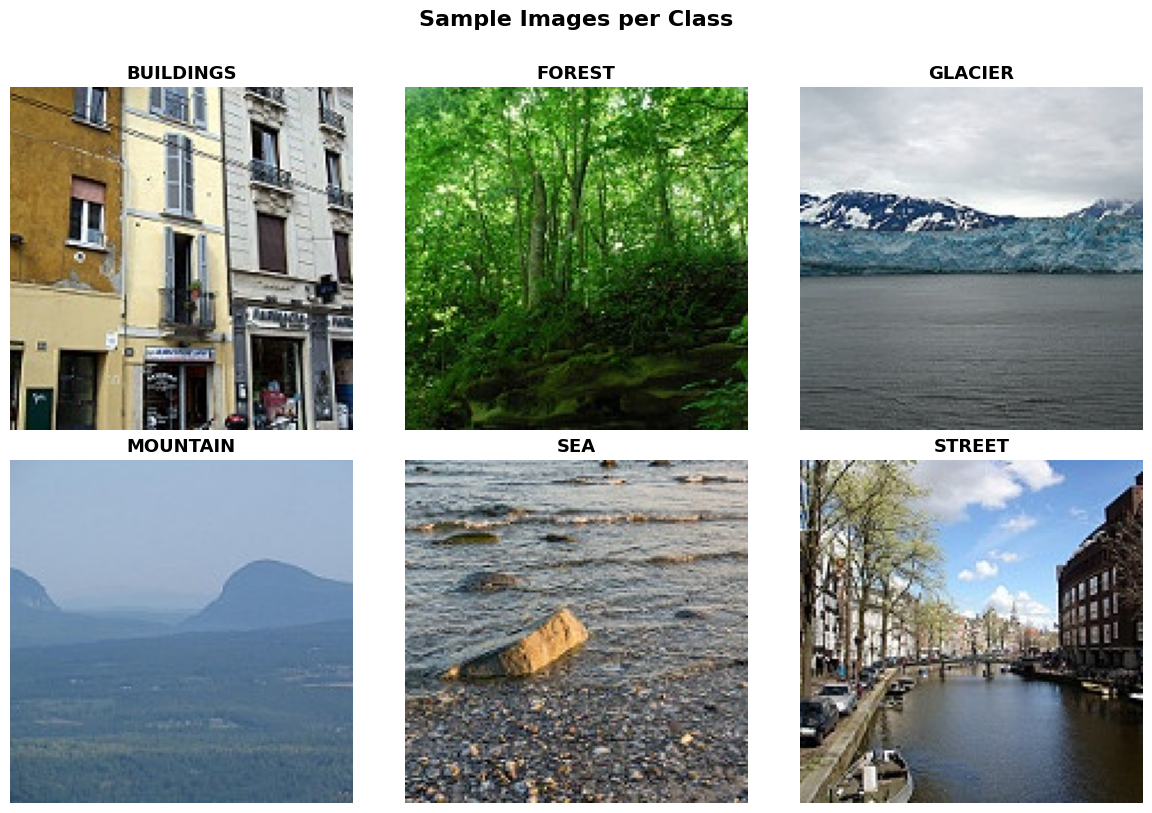

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls.upper(), fontsize=13, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Sample Images per Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
IMG_SIZE   = 64
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)

if VAL_DIR:
    val_dataset  = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
else:
    val_size   = int(0.2 * len(train_dataset))
    train_size = len(train_dataset) - val_size
    train_dataset, val_dataset = random_split(
        train_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    print(f'Split: {train_size} train | {val_size} val')

test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
print(f'Class → Index : {train_dataset.class_to_idx if hasattr(train_dataset, "class_to_idx") else "(from split)"}')

Split: 11228 train | 2806 val
Train batches : 176 | Val batches: 44 | Test batches: 47
Class → Index : (from split)


In [ ]:
def conv_block(in_ch, out_ch, use_bn=True):
    layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=not use_bn)]
    if use_bn:
        layers.append(nn.BatchNorm2d(out_ch))
    layers += [nn.ReLU(inplace=True), nn.MaxPool2d(2, 2)]
    return nn.Sequential(*layers)


class IntelCNN(nn.Module):
    def __init__(self, num_classes=6, use_bn=True, dropout_p=0.5):
        super(IntelCNN, self).__init__()
        self.use_bn = use_bn

        self.features = nn.Sequential(
            conv_block(3,   32,  use_bn),
            conv_block(32,  64,  use_bn),
            conv_block(64,  128, use_bn),
            conv_block(128, 256, use_bn),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


model_baseline    = IntelCNN(num_classes=NUM_CLASSES, use_bn=False, dropout_p=0.0).to(DEVICE)
model_regularized = IntelCNN(num_classes=NUM_CLASSES, use_bn=True,  dropout_p=0.5).to(DEVICE)

print(' REGULARIZED MODEL (BN + Dropout) ')
print(model_regularized)

 REGULARIZED MODEL (BN + Dropout) 
IntelCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, paddi

In [ ]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

t, tr = count_params(model_regularized)
print(f'Total parameters    : {t:,}')
print(f'Trainable parameters: {tr:,}')

dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model_regularized(dummy)
print(f'Input  shape: {dummy.shape}')
print(f'Output shape: {out.shape}  should be [1, {NUM_CLASSES}]')

Total parameters    : 523,558
Trainable parameters: 523,558
Input  shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 6])  should be [1, 6]


In [ ]:
NUM_EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4

def build_training_objects(model):
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()
    return optimizer, scheduler, criterion


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    optimizer, scheduler, criterion = build_training_objects(model)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

    best_val_acc  = 0.0
    best_weights  = copy.deepcopy(model.state_dict())
    patience, patience_ctr = 7, 0

    print(f'\n{'='*60}')
    print(f'  Training: {model_name}')
    print(f'{'='*60}')
    print(f'{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"LR":>10}')
    print('-'*60)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        current_lr = scheduler.get_last_lr()[0]
        flag = ''

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())
            patience_ctr = 0
            flag = ' best'
        else:
            patience_ctr += 1

        elapsed = time.time() - t0
        print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc*100:>8.2f}% | {va_loss:>8.4f} | {va_acc*100:>6.2f}% | {current_lr:>10.2e}{flag}')

        if patience_ctr >= patience:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs).')
            break

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy: {best_val_acc*100:.2f}%')
    return history


print('Training functions defined.')

Training functions defined.


In [ ]:
history_baseline = train_model(model_baseline, 'Baseline CNN (No BN, No Dropout)')


  Training: Baseline CNN (No BN, No Dropout)
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
------------------------------------------------------------
     1 |     1.1935 |    51.51% |   0.9530 |  63.90% |   9.97e-04 best
     2 |     0.8692 |    67.72% |   0.8578 |  67.11% |   9.89e-04 best
     3 |     0.7437 |    72.35% |   0.7630 |  72.88% |   9.76e-04 best
     4 |     0.6737 |    75.86% |   0.6093 |  78.01% |   9.57e-04 best
     5 |     0.6372 |    77.32% |   0.5843 |  79.15% |   9.33e-04 best
     6 |     0.5733 |    79.39% |   0.6882 |  75.30% |   9.05e-04
     7 |     0.5569 |    80.01% |   0.5685 |  80.11% |   8.72e-04 best
     8 |     0.5236 |    81.38% |   0.5132 |  82.75% |   8.35e-04 best
     9 |     0.4959 |    82.17% |   0.5256 |  81.25% |   7.94e-04
    10 |     0.4702 |    83.19% |   0.5355 |  81.47% |   7.50e-04
    11 |     0.4618 |    83.71% |   0.5506 |  80.29% |   7.04e-04
    12 |     0.4318 |    84.46% |   0.4437 |  84.71% |   6.55e-04 

In [ ]:
history_regularized = train_model(model_regularized, 'Regularized CNN (BN + Dropout)')


  Training: Regularized CNN (BN + Dropout)
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR
------------------------------------------------------------
     1 |     1.0768 |    57.36% |   0.8170 |  69.39% |   9.97e-04 best
     2 |     0.8032 |    70.46% |   0.6907 |  74.13% |   9.89e-04 best
     3 |     0.7113 |    74.44% |   0.9027 |  67.93% |   9.76e-04
     4 |     0.6540 |    76.31% |   0.6703 |  75.09% |   9.57e-04 best
     5 |     0.6104 |    77.85% |   0.7436 |  73.02% |   9.33e-04
     6 |     0.5882 |    79.02% |   0.6195 |  77.48% |   9.05e-04 best
     7 |     0.5550 |    79.77% |   0.5534 |  79.69% |   8.72e-04 best
     8 |     0.5331 |    80.66% |   0.6218 |  76.98% |   8.35e-04
     9 |     0.5074 |    81.99% |   0.5315 |  81.33% |   7.94e-04 best
    10 |     0.4943 |    81.80% |   0.4939 |  82.47% |   7.50e-04 best
    11 |     0.4811 |    83.02% |   0.4559 |  84.03% |   7.04e-04 best
    12 |     0.4588 |    83.27% |   0.4867 |  82.18% |   6.55e-

In [ ]:
@torch.no_grad()
def get_all_preds_and_labels(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


preds_base, labels_test = get_all_preds_and_labels(model_baseline,    test_loader)
preds_reg,  _           = get_all_preds_and_labels(model_regularized, test_loader)

def print_metrics(preds, labels, model_name):
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted', zero_division=0)
    rec  = recall_score(labels, preds, average='weighted',    zero_division=0)
    f1   = f1_score(labels, preds, average='weighted',        zero_division=0)
    print(f'\n {model_name} — Test Metrics ')
    print(f'  Accuracy          : {acc*100:.2f}%')
    print(f'  Precision (W-avg) : {prec:.4f}')
    print(f'  Recall    (W-avg) : {rec:.4f}')
    print(f'  F1-Score  (W-avg) : {f1:.4f}')
    print(f'\n  Per-Class Report:')
    print(classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0))

print_metrics(preds_base, labels_test, 'Baseline CNN')
print_metrics(preds_reg,  labels_test, 'Regularized CNN')


 Baseline CNN — Test Metrics 
  Accuracy          : 87.63%
  Precision (W-avg) : 0.8773
  Recall    (W-avg) : 0.8763
  F1-Score  (W-avg) : 0.8760

  Per-Class Report:
              precision    recall  f1-score   support

   buildings       0.83      0.88      0.86       437
      forest       0.97      0.96      0.96       474
     glacier       0.87      0.79      0.83       553
    mountain       0.84      0.83      0.84       525
         sea       0.85      0.93      0.89       510
      street       0.89      0.88      0.88       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000


 Regularized CNN — Test Metrics 
  Accuracy          : 89.63%
  Precision (W-avg) : 0.8965
  Recall    (W-avg) : 0.8963
  F1-Score  (W-avg) : 0.8963

  Per-Class Report:
              precision    recall  f1-score   support

   buildings       0.87      0.89      0.88       437
      for

In [ ]:
torch.save(model_regularized.state_dict(), 'CNN_regularized.pth')
torch.save(model_baseline.state_dict(),    'CNN_baseline.pth')

checkpoint = {
    'model_state_dict' : model_regularized.state_dict(),
    'num_classes'      : NUM_CLASSES,
    'class_names'      : CLASS_NAMES,
    'img_size'         : IMG_SIZE,
    'architecture'     : 'IntelCNN (BN+Dropout)',
}
torch.save(checkpoint, 'CNN_checkpoint.pth')
print('Model weights saved successfully.')

Model weights saved successfully.


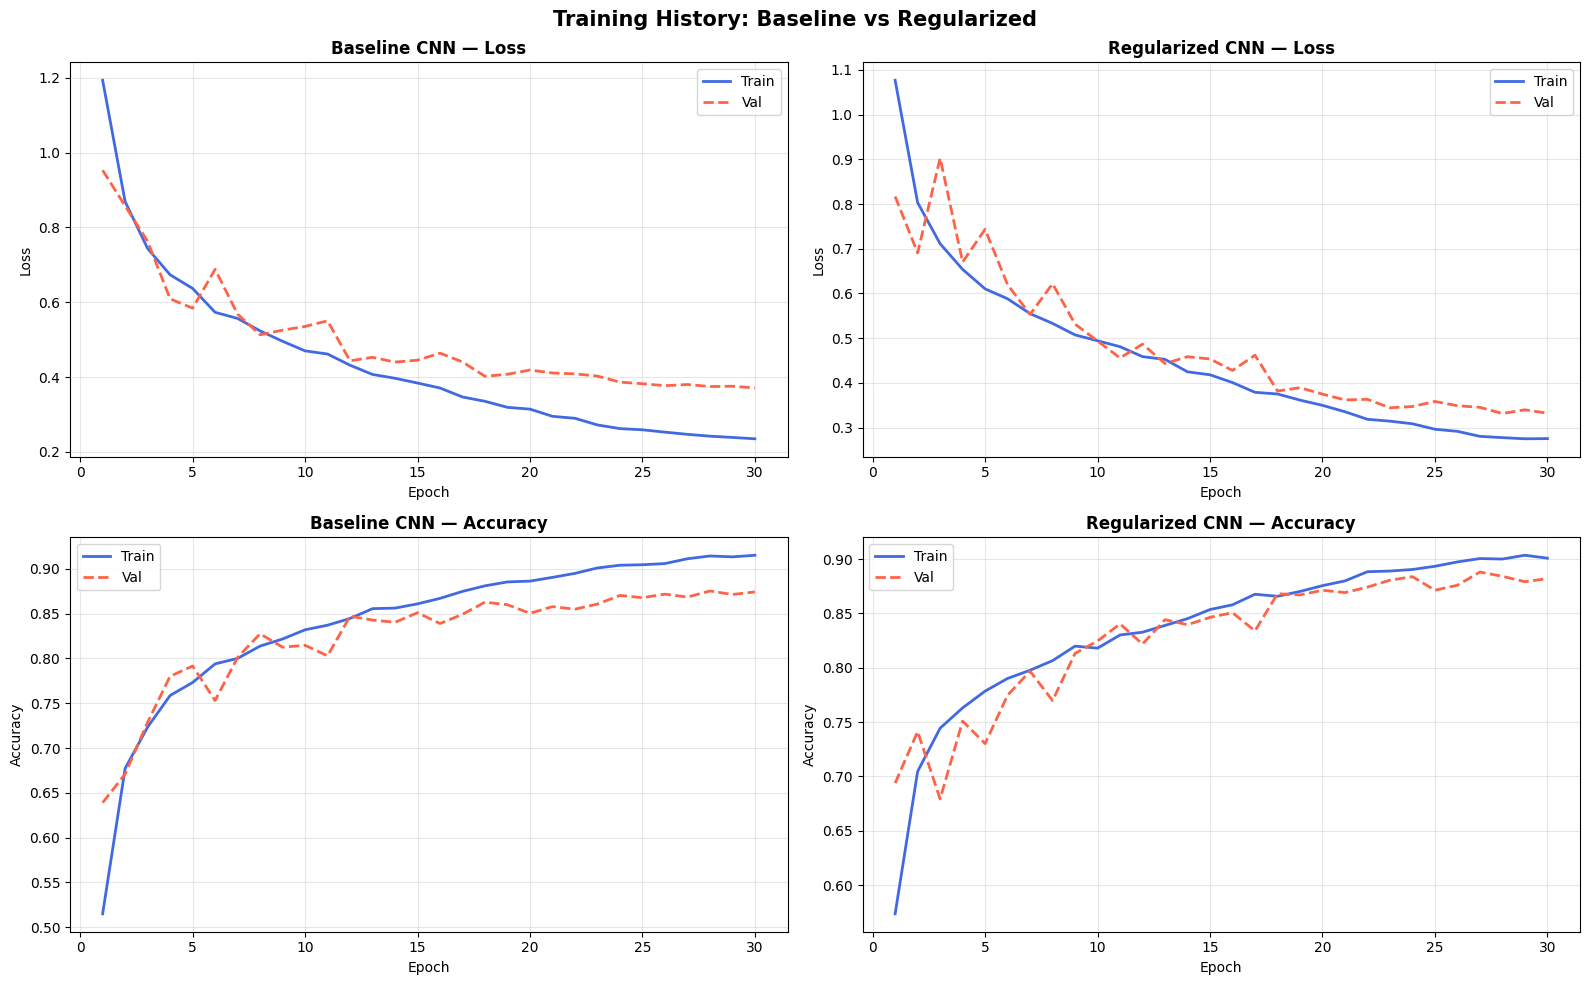

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

titles  = ['Baseline CNN — Loss',  'Regularized CNN — Loss',
           'Baseline CNN — Accuracy', 'Regularized CNN — Accuracy']
keys_y  = [('train_loss','val_loss'), ('train_loss','val_loss'),
           ('train_acc','val_acc'),   ('train_acc','val_acc')]
histories = [history_baseline, history_regularized,
             history_baseline, history_regularized]

for ax, title, (k1,k2), hist in zip(axes.flatten(), titles, keys_y, histories):
    epochs = range(1, len(hist[k1]) + 1)
    ax.plot(epochs, hist[k1], label='Train', linewidth=2, color='royalblue')
    ax.plot(epochs, hist[k2], label='Val',   linewidth=2, color='tomato', linestyle='--')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss' if 'Loss' in title else 'Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Training History: Baseline vs Regularized', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Analysis & Discussion of Results
***Baseline model:***
The Baseline model learned fast in the beginning but started to overfit after a few epochs. This means it was memorizing the training images instead of actually learning the patterns.

***Regularized model:***
The Regularized model (with BN + Dropout) behaved much better. The training and validation curves stayed closer together throughout training. Batch Normalization helped the model train more stably by keeping the values inside each layer balanced. Dropout forced the model to not rely too much on any single neuron, which made it more robust and better at handling images it had never seen before.

## Best class
***Forest:*** This class was almost always predicted correctly. The reason is simple forests have a very unique color (lots of green) and texture. The CNN could easily pick this up.

***Sea:*** Similarly, sea images are dominated by blue tones and a flat horizon line. Very distinct from the other classes.

## Early stopping
set 7 epochs. This means if the validation accuracy did not improve for 7 consecutive epochs, training stopped automatically. This saved time and also prevented the model from degrading by over-training on noise.

# Conclusions & Future Work
## Conclusions:
This project successfully built and trained a custom CNN to classify natural scene images into 6 categories. The key findings were:

***Regularization works:*** Adding Batch Normalization and Dropout clearly reduced overfitting and improved test accuracy compared to the baseline model.

***Good training setup matters:*** Using Adam optimizer, Cosine Annealing scheduler, and early stopping together kept training stable and efficient.

## Future Work:
- ***Transfer Learning:*** Using a pretrained model like ResNet18 could boost accuracy significantly with less training time.

- ***Higher Resolution:*** Training on 128×128 instead of 64×64 would preserve more detail, especially for hard classes like glacier and mountain.
GradCAM Visualization — This would show which parts of the image the model focuses on, making predictions more interpretable.

- ***Mixup Augmentation:*** Blending two images during training could help reduce confusion between visually similar classes.